# Solving Real Physics PDEs: 1D and 2D Poisson Equations

This notebook solves small one- and two-dimensional Poisson problems with homogeneous Dirichlet boundary conditions. After finite-difference discretization, both become linear systems

$$Lu=f,$$

where `L` is a positive definite discrete negative Laplacian. We solve each system using an inverse-like bounded polynomial transform, which is the kind of spectral primitive QSVT can express after block encoding.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_inverse_polynomial
from qsvt.polynomials import eval_polynomial
from qsvt.pde import dirichlet_laplacian_1d, dirichlet_laplacian_2d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

## 1D boundary-value problem

Use the standard second-difference negative Laplacian with zero boundary values. The source term combines smooth Fourier modes so the exact continuum behavior is easy to interpret.


In [2]:
# A deliberately small grid keeps the condition number in the range where
# the package's current educational inverse-polynomial helper is effective.
n_points = 6
x, L = dirichlet_laplacian_1d(n_points)

source = np.sin(np.pi * x) + 0.35 * np.sin(3.0 * np.pi * x)
eigenvalues, _ = eigh_hermitian(L)

eigenvalues[0], eigenvalues[-1]

(np.float64(9.705050945562935), np.float64(186.29494905443704))

## Normalize the operator for an inverse polynomial

`design_inverse_polynomial(gamma, degree)` approximates `gamma / y` on the positive part of the spectrum. For a positive definite Laplacian, set

$$A = L / \lambda_{\max}, \qquad \gamma = \lambda_{\min}/\lambda_{\max}.$$

Then

$$L^{-1} \approx \frac{P(A)}{\gamma\lambda_{\max}}.$$

The condition number controls how small `gamma` is. Smaller `gamma` generally needs a higher-degree polynomial, and high-resolution PDE grids quickly become challenging for the simple inverse helper used in v0.1.10.

In [3]:
lambda_min = eigenvalues[0]
lambda_max = eigenvalues[-1]
gamma = lambda_min / lambda_max
condition_number = lambda_max / lambda_min

A = L / lambda_max

gamma, condition_number

(np.float64(0.05209508360168709), np.float64(19.1956693580892))

## Solve with the inverse-like polynomial

The polynomial solution is compared to NumPy's direct linear solve for the same finite-difference system.

In [4]:
degree = 45
coeffs = design_inverse_polynomial(gamma=gamma, degree=degree)

inverse_like = apply_polynomial_to_hermitian(A, coeffs) / (gamma * lambda_max)
u_poly = inverse_like @ source

u_direct = np.linalg.solve(L, source)
relative_error = np.linalg.norm(u_poly - u_direct) / np.linalg.norm(u_direct)

relative_error

np.float64(0.014150625457763643)

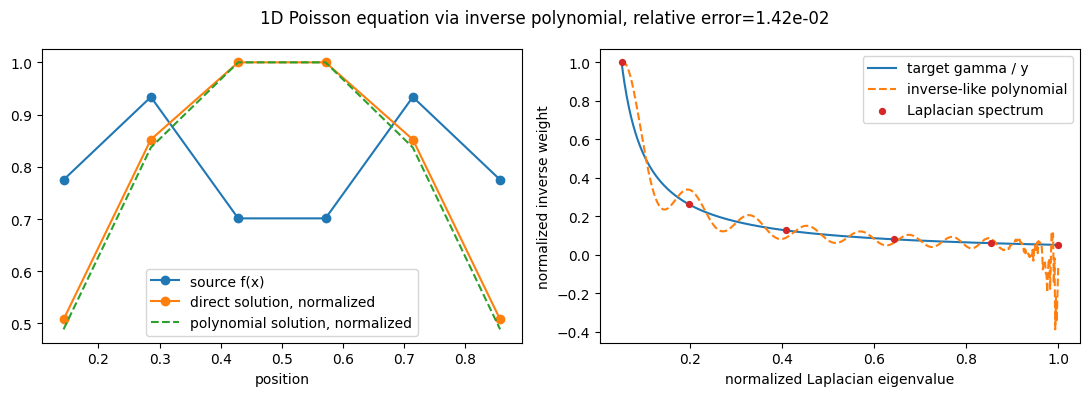

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, source, "o-", label="source f(x)")
axes[0].plot(
    x, u_direct / np.max(np.abs(u_direct)), "o-", label="direct solution, normalized"
)
axes[0].plot(
    x, u_poly / np.max(np.abs(u_poly)), "--", label="polynomial solution, normalized"
)
axes[0].set_xlabel("position")
axes[0].legend()

ys = np.linspace(gamma, 1.0, 600)
axes[1].plot(ys, gamma / ys, label="target gamma / y")
axes[1].plot(ys, eval_polynomial(coeffs, ys), "--", label="inverse-like polynomial")
axes[1].scatter(
    eigenvalues / lambda_max,
    gamma / (eigenvalues / lambda_max),
    color="tab:red",
    s=18,
    zorder=3,
    label="Laplacian spectrum",
)
axes[1].set_xlabel("normalized Laplacian eigenvalue")
axes[1].set_ylabel("normalized inverse weight")
axes[1].legend()

fig.suptitle(
    f"1D Poisson equation via inverse polynomial, relative error={relative_error:.2e}"
)
plt.tight_layout()
plt.show()

## 2D boundary-value problem

The 2D case uses a Kronecker-sum Dirichlet Laplacian. A deliberately small grid keeps the condition number in the range where the package's current educational inverse-polynomial helper remains useful.


In [6]:
nx = 4
ny = 4
x2, y2, L2 = dirichlet_laplacian_2d(nx, ny)
X2, Y2 = np.meshgrid(x2, y2, indexing="ij")

source2 = np.sin(np.pi * X2) * np.sin(np.pi * Y2)
source2 += 0.3 * np.sin(2.0 * np.pi * X2) * np.sin(np.pi * Y2)
source2_vec = source2.reshape(-1)

eigenvalues2, _ = eigh_hermitian(L2)
lambda_min2 = eigenvalues2[0]
lambda_max2 = eigenvalues2[-1]
gamma2 = lambda_min2 / lambda_max2
condition_number2 = lambda_max2 / lambda_min2

gamma2, condition_number2, L2.shape

(np.float64(0.105572809000084), np.float64(9.47213595499959), (16, 16))

## 2D inverse-like polynomial solve

As in 1D, set `A2 = L2 / lambda_max2` and rescale the polynomial output by `1 / (gamma2 * lambda_max2)`.


In [7]:
degree2 = 35
A2 = L2 / lambda_max2
coeffs2 = design_inverse_polynomial(gamma=gamma2, degree=degree2)

u_poly2_vec = apply_polynomial_to_hermitian(A2, coeffs2) @ source2_vec
u_poly2_vec = u_poly2_vec / (gamma2 * lambda_max2)
u_direct2_vec = np.linalg.solve(L2, source2_vec)

relative_error2 = np.linalg.norm(u_poly2_vec - u_direct2_vec) / np.linalg.norm(
    u_direct2_vec
)
relative_error2

np.float64(0.0965518521082745)

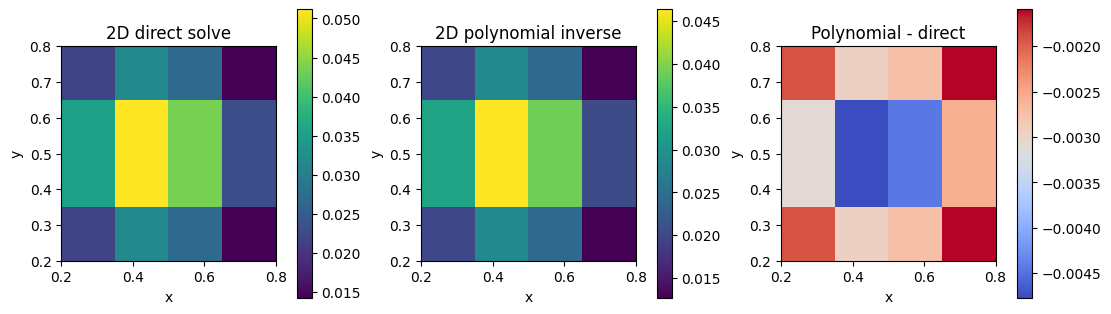

In [8]:
u_poly2 = u_poly2_vec.reshape(nx, ny)
u_direct2 = u_direct2_vec.reshape(nx, ny)
difference2 = u_poly2 - u_direct2

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for ax, field, title, cmap in zip(
    axes,
    [u_direct2, u_poly2, difference2],
    ["2D direct solve", "2D polynomial inverse", "Polynomial - direct"],
    ["viridis", "viridis", "coolwarm"],
):
    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[x2[0], x2[-1], y2[0], y2[-1]],
        cmap=cmap,
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(image, ax=ax, shrink=0.82)

plt.show()

## What this demonstrates

The Poisson equation is an elliptic physics PDE, and its discretization is a linear-system problem. The 1D and 2D sections show the same inverse-like QSVT polynomial acting as a regularized spectral inverse, while the condition-number comparison shows why higher-dimensional or finer-grid PDE systems quickly become more demanding.


## Validation

Compact checks for the expected 1D and 2D numerical behavior.


In [9]:
assert np.isfinite(relative_error)
assert relative_error < 0.05
assert gamma > 0.0
assert condition_number < 25.0
assert u_poly.shape == u_direct.shape == source.shape

assert np.isfinite(relative_error2)
assert relative_error2 < 0.15
assert gamma2 > 0.0
assert condition_number2 < 20.0
assert u_poly2.shape == u_direct2.shape == source2.shape

print(f"1D condition_number: {condition_number:.3f}")
print(f"1D relative_error: {relative_error:.3e}")
print(f"2D condition_number: {condition_number2:.3f}")
print(f"2D relative_error: {relative_error2:.3e}")
print("validation: passed")

1D condition_number: 19.196
1D relative_error: 1.415e-02
2D condition_number: 9.472
2D relative_error: 9.655e-02
validation: passed
